# Usando read_sql de iertools para cargar datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from iertools.read import read_sql 
from dateutil.parser import parse

In [2]:
f = "../Osm/Mi_primer_cubo_002/run/eplusout.sql"
cubo = read_sql(f,alias=True)
# cubo.construction_systems
data_cubo = cubo.data
data_cubo

variable_name,Ti_CUBO,Id,Ib,To,TECHO:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)
date,,,,,
2006-01-01 00:10:00,24.536431,0.0,0.0,13.766667,0.0
2006-01-01 00:20:00,24.302943,0.0,0.0,13.933333,0.0
2006-01-01 00:30:00,24.073180,0.0,0.0,14.100000,0.0
2006-01-01 00:40:00,23.846635,0.0,0.0,14.266667,0.0
2006-01-01 00:50:00,23.624291,0.0,0.0,14.433333,0.0
...,...,...,...,...,...
2006-12-31 23:20:00,27.857083,0.0,0.0,16.666667,0.0
2006-12-31 23:30:00,27.616217,0.0,0.0,16.550000,0.0
2006-12-31 23:40:00,27.377977,0.0,0.0,16.433333,0.0


In [3]:
sc = cubo.construction_systems
cubo.get_construction(sc)



Construction system:CDA15CMA0P7
Total thickness    :0.15 m
Total layers:[1]
InsideAbsorpVis:[0.7]
OutsideAbsorpVis:[0.7]
OutsideAbsorpSolar:[0.7]
InsideAbsorpThermal:[0.9]
OutsideRoughness:[2]


,NameMaterial,Conductivity,Density,SpecHeat,Thickness
0,CDA15cma0p7,2.0,2500.0,1400.0,0.15








Construction system:LADRILLO14CMA0P7
Total thickness    :0.14 m
Total layers:[1]
InsideAbsorpVis:[0.7]
OutsideAbsorpVis:[0.7]
OutsideAbsorpSolar:[0.7]
InsideAbsorpThermal:[0.9]
OutsideRoughness:[2]


,NameMaterial,Conductivity,Density,SpecHeat,Thickness
1,Ladrillo14cma0p7,1.4,1400.0,1000.0,0.14


(np.float64(13220.0), np.float64(13227.159722222223))

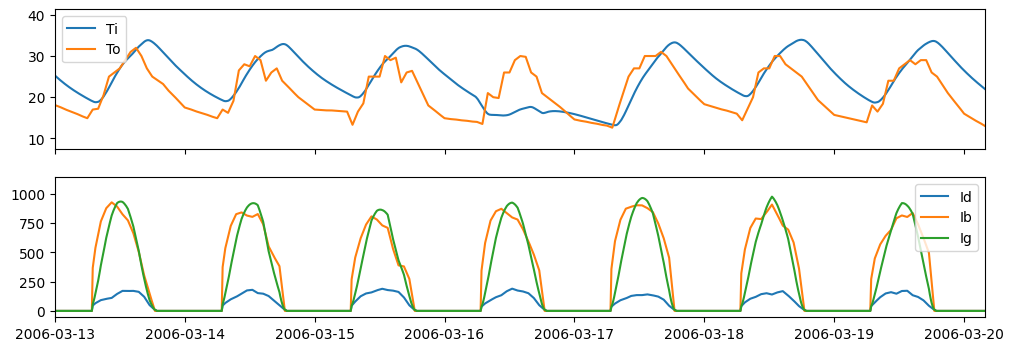

In [4]:
fig, ax = plt.subplots(2,1,figsize=(12,4),sharex=True)

f1 = parse("2006-03-13")
f2 = f1 + pd.Timedelta("7D3h50min")

ax[0].plot(data_cubo.Ti_CUBO,label="Ti")
ax[0].plot(data_cubo.To,label="To")

ax[1].plot(data_cubo.Id,label="Id") 
ax[1].plot(data_cubo.Ib,label="Ib") 
ax[1].plot(data_cubo["TECHO:Surface Outside Face Incident Solar Radiation Rate per Area (W/m2)"],label="Ig") 

ax[0].legend()
ax[1].legend()

ax[1].set_xlim(f1,f2)